## Import Liberaries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the dataset
df = pd.read_csv('/content/egypt_real_estate_listings.csv')


## Display Data

In [ ]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11594 entries, 0 to 11593
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             11594 non-null  object
 1   price           11441 non-null  object
 2   description     11565 non-null  object
 3   location        11562 non-null  object
 4   type            11566 non-null  object
 5   size            11566 non-null  object
 6   bedrooms        11553 non-null  object
 7   bathrooms       11556 non-null  object
 8   available_from  11228 non-null  object
 9   payment_method  11441 non-null  object
 10  down_payment    5440 non-null   object
dtypes: object(11)
memory usage: 996.5+ KB


In [ ]:
display(df.head())

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


### Check for Duplicates

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


## Handling Missing Values

In [ ]:
print("Checking for any remaining missing values:")
print(df.isnull().sum())

Checking for any remaining missing values:
url                  0
price              153
description         29
location            32
type                28
size                28
bedrooms            41
bathrooms           38
available_from     366
payment_method     153
down_payment      6154
dtype: int64


In [ ]:
df = df.dropna(subset=['price'])

print(df.shape)


(11441, 11)


In [ ]:
df = df.drop(columns=['url'])

In [ ]:
df['price'] = df['price'].str.replace(',', '', regex=False).astype(float)

In [ ]:
df['size_sqm'] = df['size'].str.extract(r'/\s*([\d,]+)\s*sqm')[0]
df['size_sqm'] = df['size_sqm'].str.replace(',', '', regex=False).astype(float)

In [ ]:
df = df.drop(columns=['size'])

In [ ]:
df['bedrooms'] = df['bedrooms'].str.extract(r'(\d+)')[0].astype(float)

In [ ]:
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

In [ ]:
df['description'] = df['description'].fillna('')

In [ ]:
df['payment_method'] = df['payment_method'].fillna('Unknown')

In [ ]:
print(df['bedrooms'].median())

3.0


In [ ]:
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

In [ ]:
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

In [ ]:
df['available_from'] = pd.to_datetime(
    df['available_from'],
    format='%d %b %Y',
    errors='coerce'
)

print(df['available_from'].dtype)
print(df['available_from'].isnull().sum())
print(df['available_from'].min())
print(df['available_from'].max())

datetime64[ns]
325
2023-08-03 00:00:00
2027-10-31 00:00:00


In [ ]:
df['available_year'] = df['available_from'].dt.year
df['available_month'] = df['available_from'].dt.month
df['available_day'] = df['available_from'].dt.day

print(df[['available_from', 'available_year', 'available_month', 'available_day']].head(10))
print("\nMissing values:")
print(df[['available_year', 'available_month', 'available_day']].isnull().sum())

  available_from  available_year  available_month  available_day
0     2025-08-31          2025.0              8.0           31.0
1     2025-09-02          2025.0              9.0            2.0
2     2025-08-19          2025.0              8.0           19.0
3     2025-08-26          2025.0              8.0           26.0
4     2025-09-02          2025.0              9.0            2.0
5     2025-08-26          2025.0              8.0           26.0
6     2025-07-03          2025.0              7.0            3.0
7     2025-08-26          2025.0              8.0           26.0
8     2025-08-25          2025.0              8.0           25.0
9     2025-08-07          2025.0              8.0            7.0

Missing values:
available_year     325
available_month    325
available_day      325
dtype: int64


In [ ]:
# Create an indicator showing whether the original date was missing
df['available_date_missing'] = df['available_from'].isnull().astype(int)

# Fill missing date features
df['available_year'] = df['available_year'].fillna(0)
df['available_month'] = df['available_month'].fillna(0)
df['available_day'] = df['available_day'].fillna(0)

print(df[['available_year', 'available_month', 'available_day',
          'available_date_missing']].head(10))

print("\nMissing values:")
print(df[['available_year', 'available_month', 'available_day',
          'available_date_missing']].isnull().sum())

   available_year  available_month  available_day  available_date_missing
0          2025.0              8.0           31.0                       0
1          2025.0              9.0            2.0                       0
2          2025.0              8.0           19.0                       0
3          2025.0              8.0           26.0                       0
4          2025.0              9.0            2.0                       0
5          2025.0              8.0           26.0                       0
6          2025.0              7.0            3.0                       0
7          2025.0              8.0           26.0                       0
8          2025.0              8.0           25.0                       0
9          2025.0              8.0            7.0                       0

Missing values:
available_year            0
available_month           0
available_day             0
available_date_missing    0
dtype: int64


In [ ]:
df = df.drop(columns=['available_from'])

print(df.columns)

Index(['price', 'description', 'location', 'type', 'bedrooms', 'bathrooms',
       'payment_method', 'down_payment', 'size_sqm', 'available_year',
       'available_month', 'available_day', 'available_date_missing'],
      dtype='object')


In [ ]:
df = df.drop(columns=['down_payment', 'down_payment_amount'], errors='ignore')

## EDA

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (11441, 12)

Columns:
['price', 'description', 'location', 'type', 'bedrooms', 'bathrooms', 'payment_method', 'size_sqm', 'available_year', 'available_month', 'available_day', 'available_date_missing']

Data types:
price                     float64
description                object
location                   object
type                       object
bedrooms                  float64
bathrooms                 float64
payment_method             object
size_sqm                  float64
available_year            float64
available_month           float64
available_day             float64
available_date_missing      int64
dtype: object

Missing values:
price                     0
description               0
location                  0
type                      0
bedrooms                  0
bathrooms                 0
payment_method            0
size_sqm                  0
available_year            0
available_month           0
available_day             0
available_date_missing    0
dty

In [ ]:
print("\nNumerical summary:")
print(df.describe())


Numerical summary:
              price      bedrooms     bathrooms      size_sqm  available_year  \
count  1.144100e+04  11441.000000  11441.000000  1.144100e+04    11441.000000   
mean   1.576550e+07      2.873001      2.807622  1.576653e+03     1967.485884   
std    2.006697e+07      1.058369      1.210371  1.478230e+05      336.432585   
min    2.000000e+05      1.000000      1.000000  2.000000e+00        0.000000   
25%    6.050000e+06      2.000000      2.000000  1.200000e+02     2025.000000   
50%    1.065000e+07      3.000000      3.000000  1.600000e+02     2025.000000   
75%    1.800000e+07      3.000000      3.000000  2.200000e+02     2025.000000   
max    3.750000e+08      7.000000      7.000000  1.581169e+07     2027.000000   

       available_month  available_day  available_date_missing  
count     11441.000000   11441.000000            11441.000000  
mean          7.942575      15.198934                0.028407  
std           1.626681      12.366650                0.166

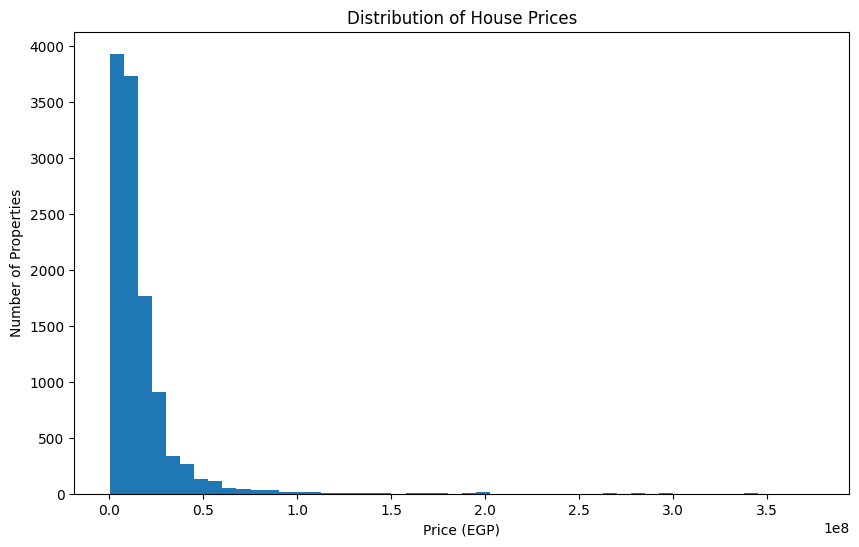

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50)
plt.xlabel('Price (EGP)')
plt.ylabel('Number of Properties')
plt.title('Distribution of House Prices')
plt.show()

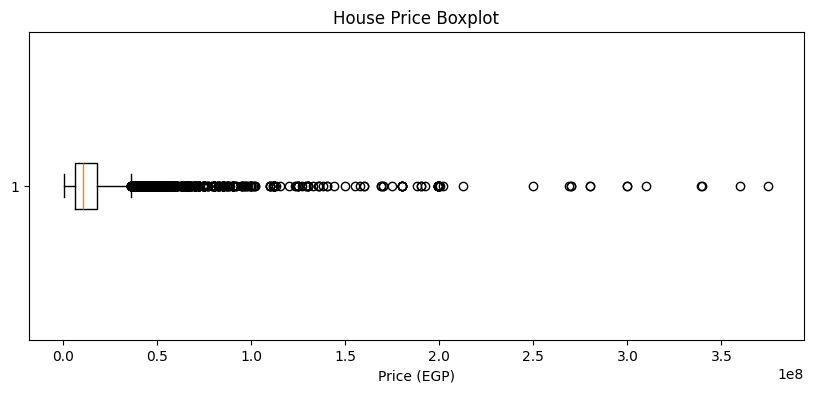

In [ ]:
plt.figure(figsize=(10, 4))
plt.boxplot(df['price'], vert=False)
plt.xlabel('Price (EGP)')
plt.title('House Price Boxplot')
plt.show()

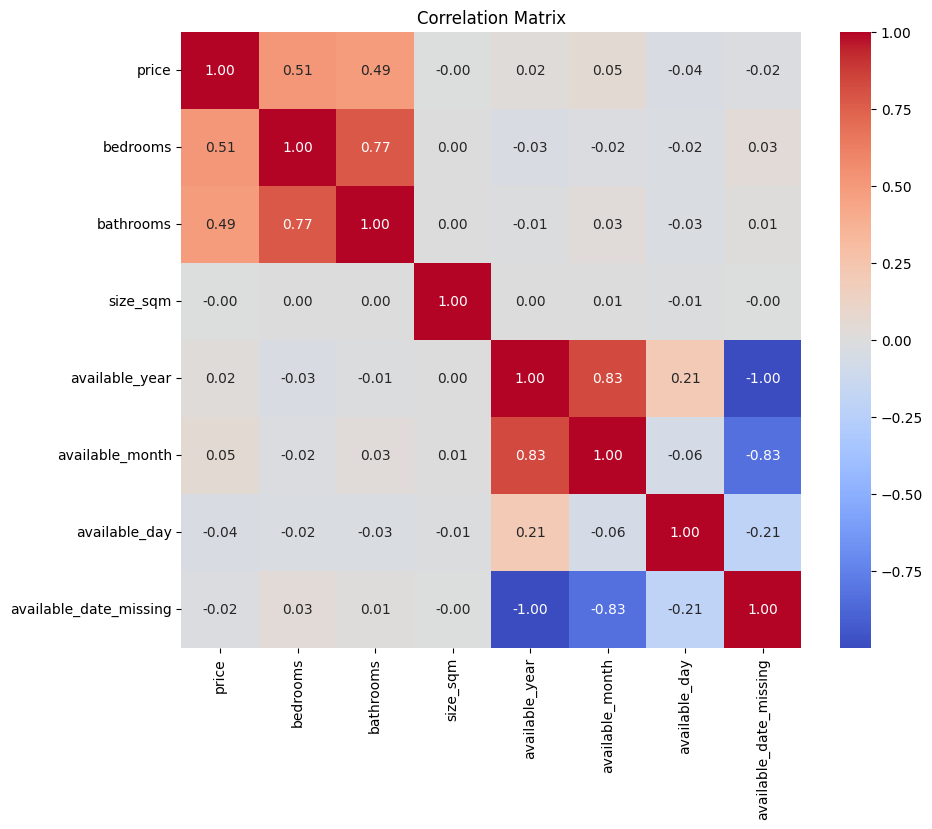

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'size_sqm',
    'available_year',
    'available_month',
    'available_day',
    'available_date_missing'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Correlation Matrix Observations

- **`size_sqm` has almost no correlation with `price` (~0.00).** This is unexpected — size is usually one of the biggest factors in house price. It likely means the size extraction step isn't working correctly for many rows. We should check how many values are missing/incorrect before using this feature.

- **The date-related features (`available_year`, `available_month`, `available_day`, `available_date_missing`) show fake-looking correlations.** This happened because missing dates were filled with `0`, which makes the "missing" flag and the date values look perfectly linked (correlation of -1.00). This isn't a real pattern — we should fix how missing dates are handled before using these features in the model.

- **`bedrooms` and `bathrooms` are fairly correlated (0.77).** This makes sense (bigger houses have more of both), but it's something to keep in mind — it could affect certain regression models later.

**Next step:** Fix the `size_sqm` extraction and the missing-date handling before selecting features for the model.

### Area VS Price

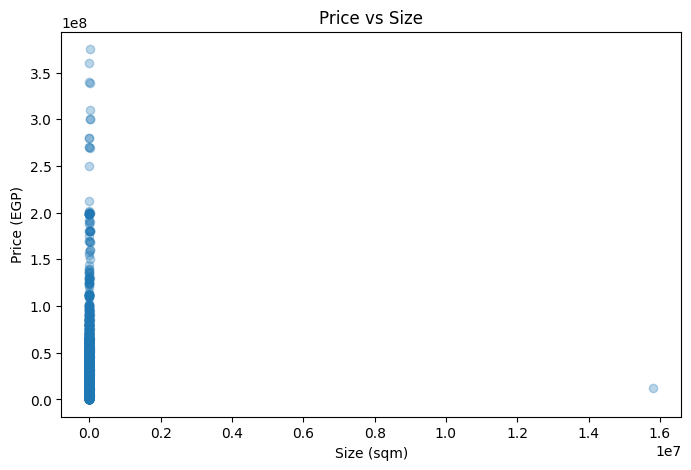

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['size_sqm'], df['price'], alpha=0.3)
plt.xlabel('Size (sqm)')
plt.ylabel('Price (EGP)')
plt.title('Price vs Size')
plt.show()

###Does Location affect price?

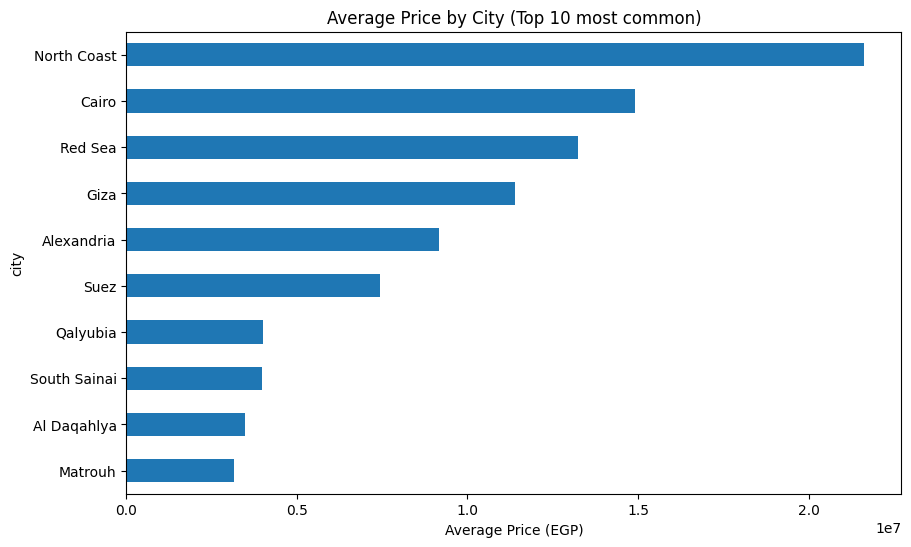

In [ ]:
# Simplify location: keep only the last part (city/governorate)
df['city'] = df['location'].str.split(',').str[-1].str.strip()

top_cities = df['city'].value_counts().head(10).index
avg_price_by_city = df[df['city'].isin(top_cities)].groupby('city')['price'].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_price_by_city.plot(kind='barh')
plt.xlabel('Average Price (EGP)')
plt.title('Average Price by City (Top 10 most common)')
plt.show()

###Does Property Type affect price?

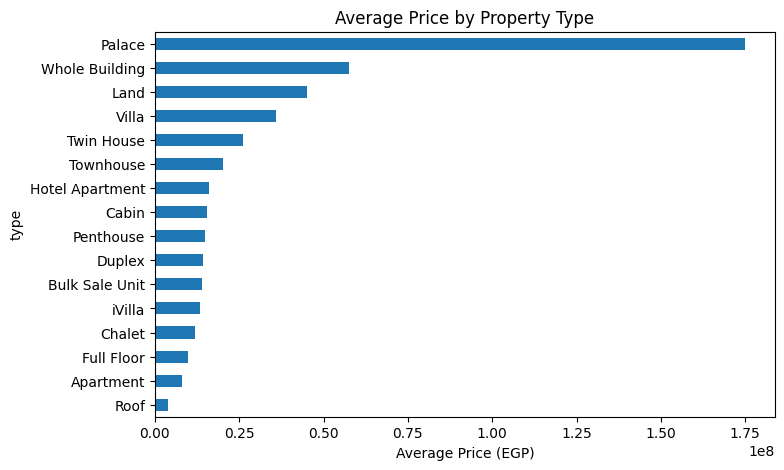

In [ ]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values()

plt.figure(figsize=(8, 5))
avg_price_by_type.plot(kind='barh')
plt.xlabel('Average Price (EGP)')
plt.title('Average Price by Property Type')
plt.show()

###Features & Target section

In [ ]:
features = ['city', 'type', 'size_sqm', 'bedrooms', 'bathrooms']
target = 'price'

X = df[features]
y = df[target]

print(X.head())
print(y.head())

          city       type  size_sqm  bedrooms  bathrooms
0      Red Sea     Chalet      68.0       1.0        1.0
1         Giza      Villa     220.0       4.0        4.0
2  North Coast     Chalet     118.0       2.0        2.0
3        Cairo  Apartment     166.0       3.0        2.0
4        Cairo      Villa     400.0       7.0        7.0
0     8000000.0
1    25000000.0
2    15135000.0
3    12652000.0
4    45250000.0
Name: price, dtype: float64


# Train/test split + preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = ['city', 'type']
numerical_features = ['size_sqm', 'bedrooms', 'bathrooms']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')  # numerical features pass through unchanged

# Train two models (baseline + comparison)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Model 1: simple baseline
model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
model_1.fit(X_train, y_train)

# Model 2: for comparison
model_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])
model_2.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'type'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

# Evaluate with MAE and R²

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

for name, model in [('Linear Regression', model_1), ('Random Forest', model_2)]:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name} -> MAE: {mae:,.0f} EGP | R²: {r2:.2f}")

Linear Regression -> MAE: 8,651,757 EGP | R²: 0.31
Random Forest -> MAE: 5,493,875 EGP | R²: 0.66


# Save, reload, and test

In [ ]:
final_model = model_2  # Random Forest — chosen for lower MAE and higher R²

In [ ]:
import joblib

joblib.dump(final_model, 'house_price_model.pkl')

# Reload and test one prediction
loaded_model = joblib.load('house_price_model.pkl')
sample = X_test.iloc[[0]]
print("Predicted:", loaded_model.predict(sample)[0])
print("Actual:", y_test.iloc[0])

Predicted: 7051649.999999999
Actual: 9000000.0
